# HRRR QPF vs. Stage IV QPE Analysis



```{image} ../thumbnails/HRRR_24hr_09012021.png
:alt: HRRR QPF
:width: 200px
```

---

## Overview
This notebook will run through the following procedures:

1. Prerequisites
2. Imports
1. Reading in HRRR Data
1. Plotting HRRR Data

Future additions: 

1. Reading in Stage IV data
2. Regridding Stage IV Data
3. Comparing HRRR vs. Stage IV

## Prerequisites (somewhat uncertain as of yet)
This section was inspired by [this template](https://github.com/alan-turing-institute/the-turing-way/blob/master/book/templates/chapter-template/chapter-landing-page.md) of the wonderful [The Turing Way](https://the-turing-way.netlify.app) Jupyter Book.

Following your overview, tell your reader what concepts, packages, or other background information they'll **need** before learning your material. Tie this explicitly with links to other pages here in Foundations or to relevant external resources. Remove this body text, then populate the Markdown table, denoted in this cell with `|` vertical brackets, below, and fill out the information following. In this table, lay out prerequisite concepts by explicitly linking to other Foundations material or external resources, or describe generally helpful concepts.

Label the importance of each concept explicitly as **helpful/necessary**.

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy) | Necessary | |
| [Understanding of NetCDF](https://foundations.projectpythia.org/core/data-formats/netcdf-cf) | Helpful | Familiarity with metadata structure |
| Project management | Helpful | |

- **Time to learn**: estimate in minutes. For a rough idea, use 5 mins per subsection, 10 if longer; add these up for a total. Safer to round up and overestimate.
- **System requirements**:
    - Populate with any system, version, or non-Python software requirements if necessary
    - Otherwise use the concepts table above and the Imports section below to describe required packages as necessary
    - If no extra requirements, remove the **System requirements** point altogether

---

## Imports


In [14]:

from herbie import Herbie
from herbie import paint
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

## Loading in HRRR Data

Setting beginning and ending times of the 24 hour precipitation period of interest, then load in all HRRR initializations that cover the whole period

In [20]:
init0 = "2021-09-01 12:00"
end0 = "2021-09-02 12:00"

In [21]:
H = Herbie(
    init0,
    model="hrrr",
    product="sfc",
    fxx=24,
)

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2021-Sep-01 12:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ aws


In [22]:
from herbie import Herbie
import pandas as pd

# --------------------------
# 1️⃣ User settings
# --------------------------
valid_end = pd.Timestamp(end0)   # end of 24h valid period
valid_start = valid_end - pd.Timedelta("24h")

# HRRR inits: 0, 6, 12, 18, 24 hours before valid_start
init_offsets = [0, 6, 12, 18, 24]  # hours before valid_start

# Domain bounds
lat_min, lat_max = 39, 48
lon_min, lon_max = 280, 295  # degrees east

# --------------------------
# 2️⃣ Loop through inits and calculate 24h QPF for each
# --------------------------
precip_runs = {}

for offset in init_offsets:
    init = valid_start - pd.Timedelta(hours=offset)
    fxx_end = int((valid_end - init).total_seconds() / 3600)
    fxx_start = fxx_end - 24

    print(f"Init: {init} | fxx range: {fxx_start}–{fxx_end}")

    # Load accumulated precip at start and end forecast hours
    H_start = Herbie(init, model="hrrr", product="sfc", fxx=fxx_start)
    H_end   = Herbie(init, model="hrrr", product="sfc", fxx=fxx_end)

    qpf_start = H_start.xarray("APCP:surface")
    qpf_end   = H_end.xarray("APCP:surface")

    # Compute 24-hour precip by subtraction
    qpf_24h = qpf_end - qpf_start

    # Subset domain
    lat_idx = ((qpf_24h.latitude >= lat_min) & (qpf_24h.latitude <= lat_max)).any(dim="x")
    lon_idx = ((qpf_24h.longitude >= lon_min) & (qpf_24h.longitude <= lon_max)).any(dim="y")

    y_min = int(lat_idx.argmax().values)
    y_max = int(lat_idx[::-1].argmax().values)
    x_min = int(lon_idx.argmax().values)
    x_max = int(lon_idx[::-1].argmax().values)

    ds_subset = qpf_24h.isel(
        y=slice(y_min, len(lat_idx) - y_max),
        x=slice(x_min, len(lon_idx) - x_max)
    )

    # Convert to inches
    precip_in = ds_subset.squeeze() / 25.4

    # Store in dictionary
    precip_runs[f"init_{init.strftime('%Y%m%d%H')}"] = precip_in



Init: 2021-09-01 12:00:00 | fxx range: 0–24
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2021-Sep-01 12:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2021-Sep-01 12:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ aws
Init: 2021-09-01 06:00:00 | fxx range: 6–30
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2021-Sep-01 06:00 UTC F06 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2021-Sep-01 06:00 UTC F30 ┊ GRIB2 @ aws ┊ IDX @ aws
Init: 2021-09-01 00:00:00 | fxx range: 12–36
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2021-Sep-01 00:00 UTC F12 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2021-Sep-01 00:00 UTC F36 ┊ GRIB2 @ aws ┊ IDX @ aws
Init: 2021-08-31 18:00:00 | fxx range: 18–42
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2021-Aug-31 18:00 UTC F18 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2021-Aug-31 18:00 UTC F42 ┊ GRIB2 @ aws ┊ IDX @ aws
Init: 2021-08-31 12:00:00 | fxx range: 24–48
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2021-Aug-31 12:00 UTC F24 ┊ 

### Subsetting for Accumulated Precipitation
Then, we can subset the data for the domain we want, so that we can plot in the next subsection

In [23]:
# Get accumulated precip (kg/m^2 = mm)
ds_qpf = H.xarray("APCP:surface")
# Find index ranges that cover your domain
lat_idx = ((ds_qpf.latitude >= 39) & (ds_qpf.latitude <= 48)).any(dim="x")
lon_idx = ((ds_qpf.longitude >= 280) & (ds_qpf.longitude <= 295)).any(dim="y")

# Get the slice indices
y_min = int(lat_idx.argmax().values)
y_max = int(lat_idx[::-1].argmax().values)
x_min = int(lon_idx.argmax().values)
x_max = int(lon_idx[::-1].argmax().values)

# Slice directly by index
ds_subset_hrrr = ds_qpf.isel(y=slice(y_min, len(lat_idx) - y_max),
                        x=slice(x_min, len(lon_idx) - x_max))
# Convert mm to inches
precip = ds_subset_hrrr["tp"].squeeze() / 25.4

### Plotting HRRR QPF for each relevant period
Keep up the good work! A note, *try to avoid using code comments as narrative*, and instead let them only exist as brief clarifications where necessary.

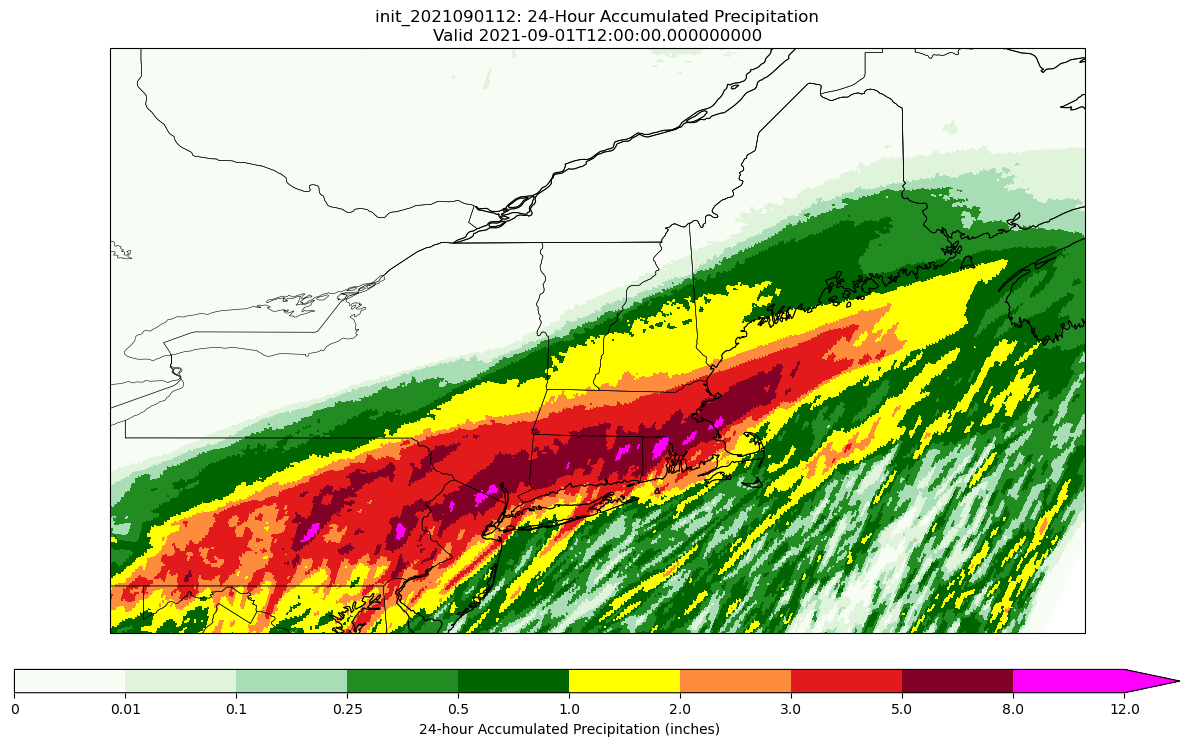

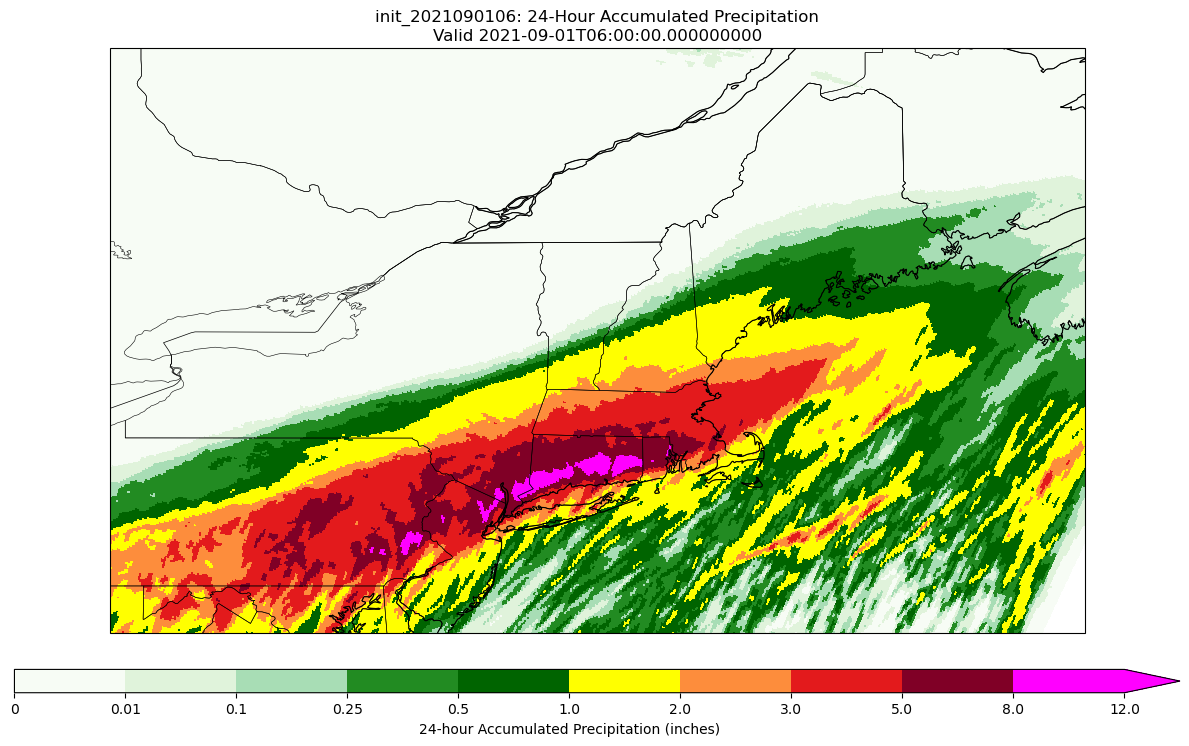

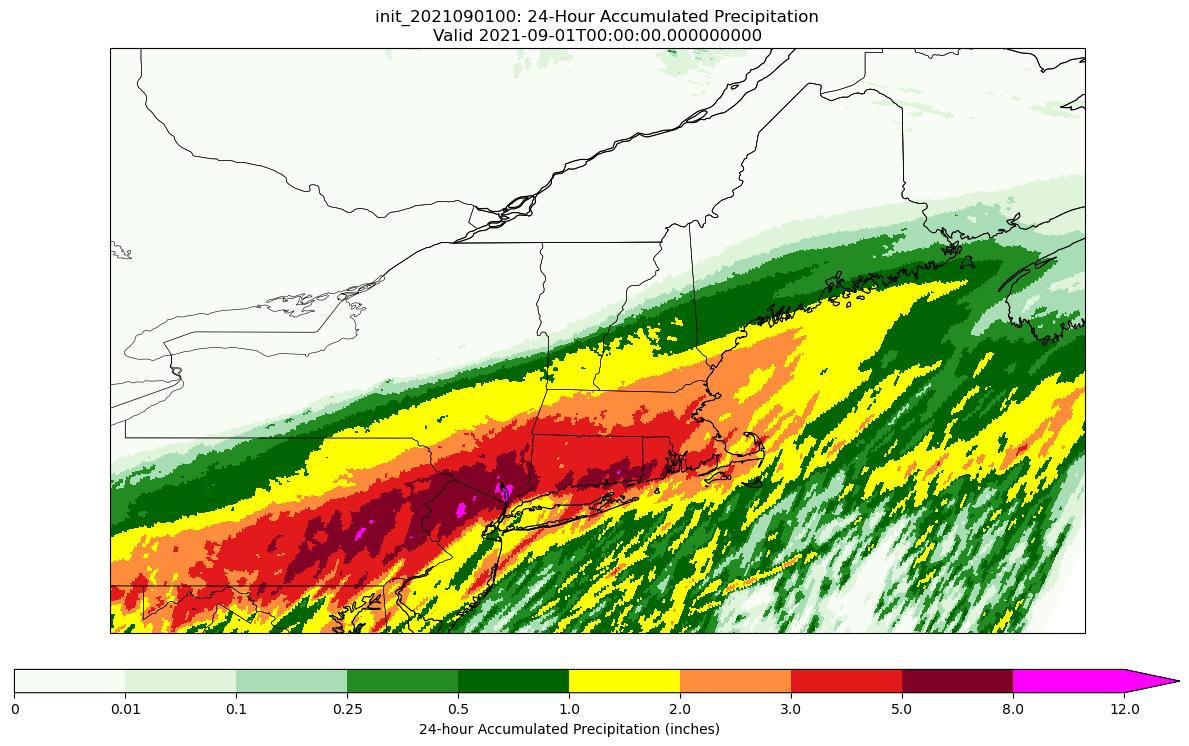

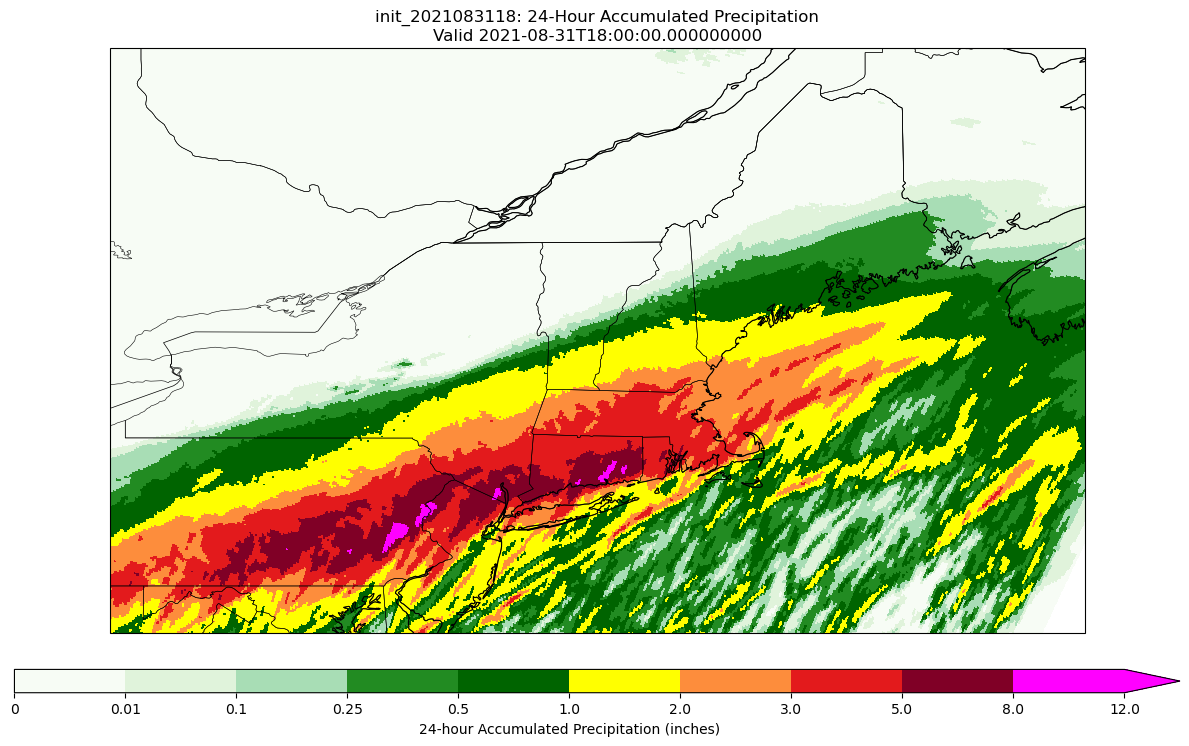

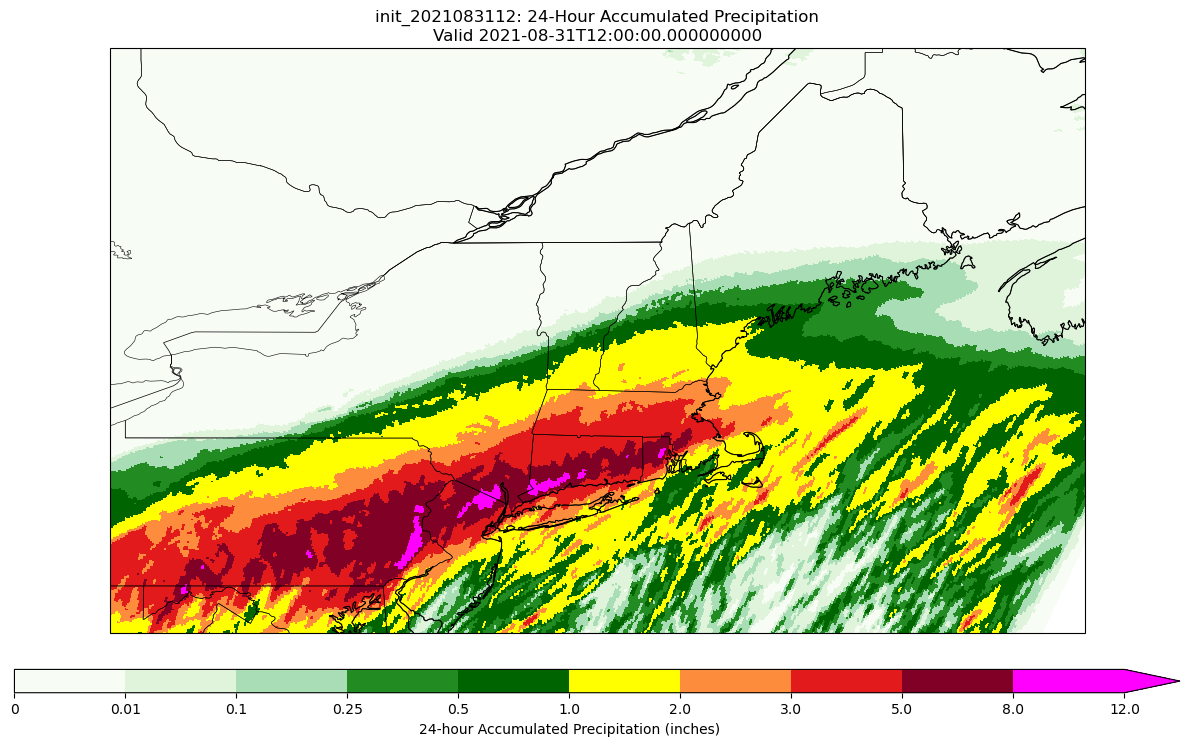

In [25]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm, ListedColormap

# --- Define custom bins for QPE (inches) ---
bounds = [0, 0.01, 0.1, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0, 12.0]
colors = [
    "#f7fcf5", "#e0f3db", "#a8ddb5",
    "forestgreen", "darkgreen", "yellow",
    "#fd8d3c", "#e31a1c", "#800026", "#FF00FF"
]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

# --- Loop through each 24-hour precip dataset ---
for name, ds_subset_hrrr in precip_runs.items():
    lats = ds_subset_hrrr["latitude"].values
    lons = ds_subset_hrrr["longitude"].values
    precip = ds_subset_hrrr["tp"].values  # convert meters → inches

    # Create figure
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.4)

    # Plot precip field
    mesh = ax.pcolormesh(
        lons, lats, precip,
        cmap=cmap, norm=norm,
        transform=ccrs.PlateCarree()
    )

    # Add colorbar
    cbar = plt.colorbar(
        mesh, orientation="horizontal", pad=0.05, aspect=50,
        boundaries=bounds, extend="max"
    )
    cbar.set_label("24-hour Accumulated Precipitation (inches)")
    cbar.set_ticks(bounds)
    cbar.set_ticklabels([str(b) for b in bounds])

    # Set extent roughly over NYS
    ax.set_extent([-80, -65, 39, 48], crs=ccrs.PlateCarree())

    # Add title
    valid_time = str(ds_subset_hrrr.time.values)
    ax.set_title(f"{name}: 24-Hour Accumulated Precipitation\nValid {valid_time}")

    plt.tight_layout()
    plt.show()

## Stage IV Data
Loading in Stage IV observed precipitation data. This will be further updates as the project moves along. 

## Helpful markdown notes for the future:



:::{note}
Your relevant information here!
:::

Some other admonitions you can put in ([there are 10 total](https://mystmd.org/guide/admonitions#admonitions-list)):

:::{hint}
A helpful hint.
:::

:::{warning}
Be careful!
:::

:::{danger}
Scary stuff be here.
:::

---

## Summary
More to come!

## Resources and references (will do when I have references)
Finally, be rigorous in your citations and references as necessary. Give credit where credit is due. Also, feel free to link to relevant external material, further reading, documentation, etc. Then you're done! Give yourself a quick review, a high five, and send us a pull request. A few final notes:
 - `Kernel > Restart Kernel and Run All Cells...` to confirm that your notebook will cleanly run from start to finish
 - `Kernel > Restart Kernel and Clear All Outputs...` before committing your notebook, our machines will do the heavy lifting
 - Take credit! Provide author contact information if you'd like; if so, consider adding information here at the bottom of your notebook
 - Give credit! Attribute appropriate authorship for referenced code, information, images, etc.
 - Only include what you're legally allowed: **no copyright infringement or plagiarism**
 
Thank you for your contribution!